# RAGDoll citation-support dashboard

This notebook visualizes the compiled citation-support judgments in `evaluation-results/aus-agent/support-bedrock`. Run all cells from the repository root environment.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 140)

cwd = Path.cwd().resolve()
repo = next((p for p in [cwd, *cwd.parents] if (p / 'evaluation-results').is_dir()), None)
assert repo is not None, 'Could not locate repository root from the notebook working directory'
results = repo / 'evaluation-results' / 'aus-agent' / 'support-bedrock'
details_path = results / 'judgments.csv'
summary_path = results / 'judgments.summary.csv'
assert details_path.exists(), f'Missing {details_path}'
assert summary_path.exists(), f'Missing {summary_path}'

details = pd.read_csv(details_path)
summary = pd.read_csv(summary_path)
print(f'Loaded {len(details):,} judgments across {details.run_id.nunique()} runs and {details.qid.nunique()} topics.')

Loaded 4,246 judgments across 15 runs and 110 topics.


## Overall results

In [2]:
overall = pd.Series({
    'Judgments': len(details),
    'Runs': details.run_id.nunique(),
    'Topics': details.qid.nunique(),
    'Full support': (details.support_label == 'FS').sum(),
    'Partial support': (details.support_label == 'PS').sum(),
    'No support': (details.support_label == 'NS').sum(),
    'Judge errors': details.support_label.isna().sum(),
})
display(overall.to_frame('value'))
display(summary.sort_values('total', ascending=False).reset_index(drop=True))

,value
Judgments,4246
Runs,15
Topics,110
Full support,1591
Partial support,2125
No support,402
Judge errors,128


,run_id,total,full_support,partial_support,no_support,judge_errors,full_support_rate,partial_or_full_rate
0,aus-agent-test-v2,1931,752,936,176,67,0.389436,0.874158
1,aus-agent-test-full,1191,446,590,122,33,0.374475,0.869857
2,aus-agent-dev-full,781,271,407,83,20,0.346991,0.868118
3,aus-agent-creative-check,229,72,135,17,5,0.314410,0.903930
4,viewer-20260717T020901,26,15,11,0,0,0.576923,1.000000
5,aus-agent-discovery-check,21,13,8,0,0,0.619048,1.000000
6,aus-agent-math-check,19,11,7,0,1,0.578947,0.947368
7,viewer-20260717T020657,15,5,6,2,2,0.333333,0.733333
8,aus-agent-protocol-check,12,3,8,1,0,0.250000,0.916667
9,aus-agent-protocol-check-v2,11,0,10,1,0,0.000000,0.909091


## Verdict composition by run

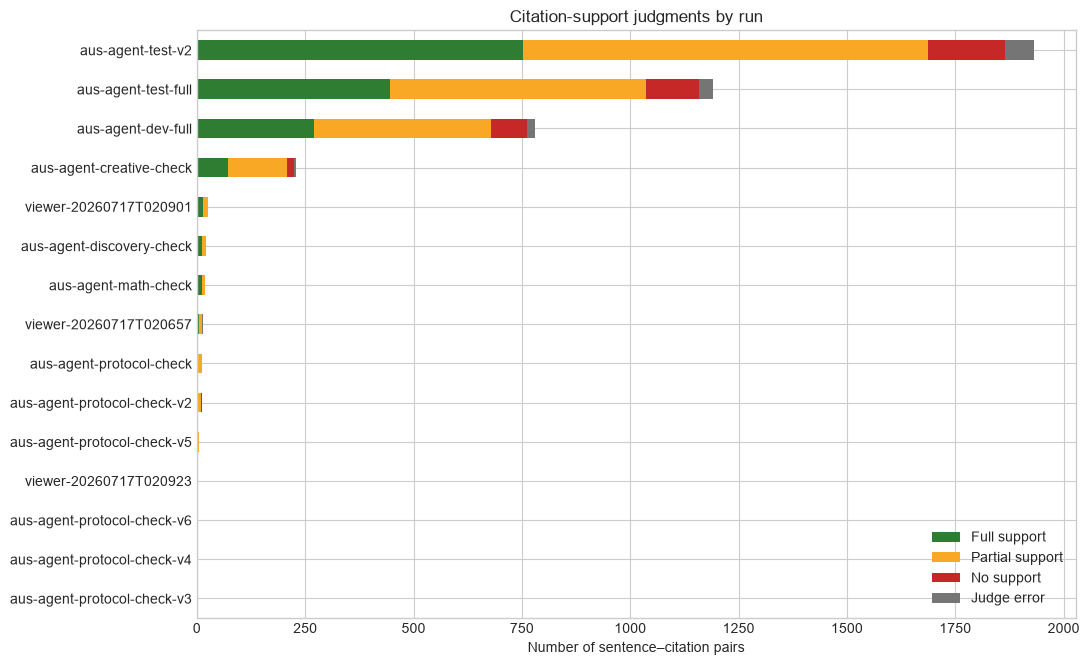

In [3]:
plot_data = summary.set_index('run_id')[['full_support', 'partial_support', 'no_support', 'judge_errors']]
plot_data = plot_data.loc[plot_data.sum(axis=1).sort_values(ascending=True).index]
ax = plot_data.plot.barh(
    stacked=True, figsize=(11, max(5, len(plot_data) * 0.45)),
    color=['#2e7d32', '#f9a825', '#c62828', '#757575']
)
ax.set(title='Citation-support judgments by run', xlabel='Number of sentence–citation pairs', ylabel='')
ax.legend(['Full support', 'Partial support', 'No support', 'Judge error'], loc='lower right')
plt.tight_layout()
plt.show()

## Support rates by run

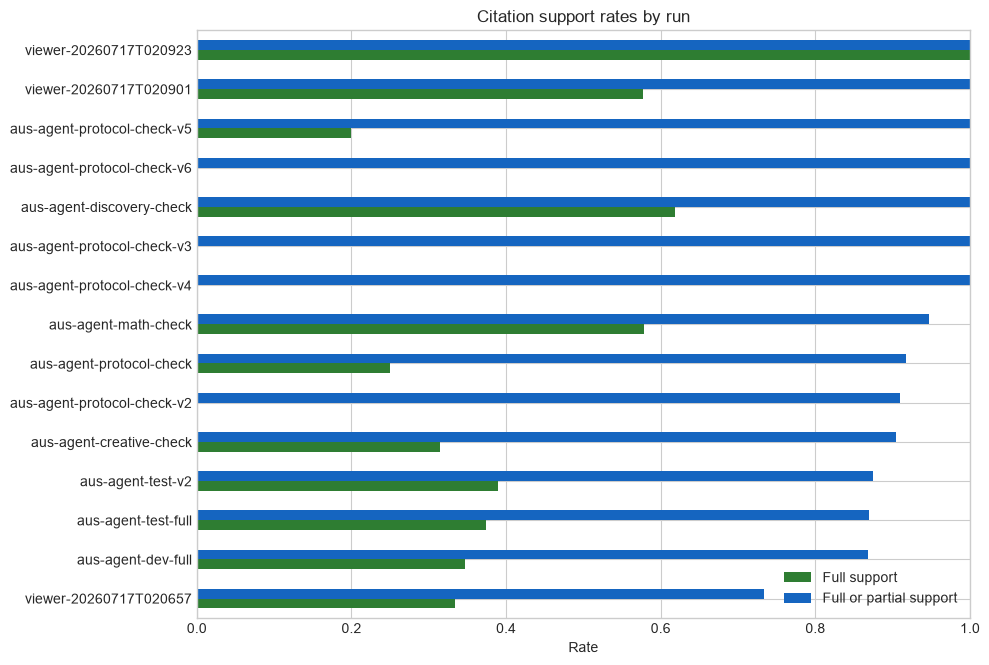

In [4]:
rates = summary.set_index('run_id')[['full_support_rate', 'partial_or_full_rate']].sort_values('partial_or_full_rate')
ax = rates.plot.barh(figsize=(10, max(5, len(rates) * 0.45)), color=['#2e7d32', '#1565c0'])
ax.set(title='Citation support rates by run', xlabel='Rate', ylabel='', xlim=(0, 1))
ax.legend(['Full support', 'Full or partial support'], loc='lower right')
plt.tight_layout()
plt.show()

## Topic-level support

,run_id,qid,mean_support,citations
131,aus-agent-test-v2,rag2026-43,0.363636,22
115,aus-agent-test-v2,rag2026-28,0.372340,47
31,aus-agent-dev-full,6847465956a0f6376a605476,0.384615,13
85,aus-agent-test-full,rag2026-43,0.396552,29
68,aus-agent-test-full,rag2026-28,0.418919,37
82,aus-agent-test-full,rag2026-40,0.439394,33
123,aus-agent-test-v2,rag2026-36,0.450000,20
42,aus-agent-protocol-check-v2,adhoc,0.454545,11
5,aus-agent-creative-check,684397d188c1deceb49af325,0.462963,27
15,aus-agent-dev-full,684397d188c1deceb49af325,0.471429,35


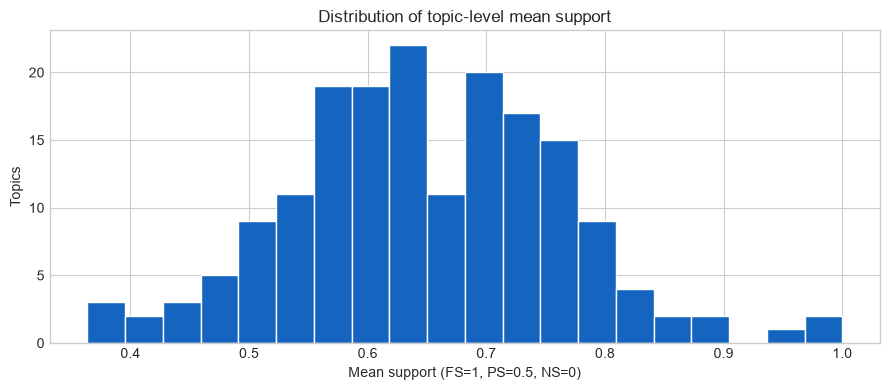

In [5]:
valid = details[details.support_label.isin(['FS', 'PS', 'NS'])].copy()
valid['support_score'] = valid.support_label.map({'FS': 1.0, 'PS': 0.5, 'NS': 0.0})
topic_scores = (valid.groupby(['run_id', 'qid'], as_index=False)
                .agg(mean_support=('support_score', 'mean'), citations=('support_score', 'size')))
display(topic_scores.sort_values(['mean_support', 'citations'], ascending=[True, False]).head(30))

ax = topic_scores.mean_support.hist(bins=20, figsize=(9, 4), color='#1565c0', edgecolor='white')
ax.set(title='Distribution of topic-level mean support', xlabel='Mean support (FS=1, PS=0.5, NS=0)', ylabel='Topics')
plt.tight_layout()
plt.show()

## Unsupported and failed judgmentsReview the claim beside its cited-passage excerpt. Use the filters to focus on a run or verdict.

In [6]:
RUN = None  # e.g. 'aus-agent-dev-full'
VERDICTS = ['No Support', 'Judge Error']

review = details[details.support_verdict.isin(VERDICTS)].copy()
if RUN:
    review = review[review.run_id == RUN]
display(review[[
    'run_id', 'qid', 'sentence_index', 'docid', 'support_verdict',
    'statement', 'citation_excerpt', 'error'
]].reset_index(drop=True))

,run_id,qid,sentence_index,docid,support_verdict,statement,citation_excerpt,error
0,aus-agent-dev-full,683a58c9a7e7fe4e7695846f,2,shard_00218_7394,Judge Error,"Students in that class rarely see anything beyond the inscribed angle theorem, the Pythagorean theorem, and the law of cosines applied t...",Geometry Ceva's theorem tells us when three cevians emanating from the three vertices of a triangle are concurrent. This is a handy theo...,could not parse support label
1,aus-agent-dev-full,683a58c9a7e7fe4e7695846f,11,shard_03744_66439,No Support,"A second staple is Ptolemy's theorem, which states that for any cyclic quadrilateral ABCD the product of the diagonals equals the sum of...",". Ptolemy's theorem In Euclidean geometry, Ptolemy's theorem is a relation between the four sides and two diagonals of a cyclic quadrila...",NaN
2,aus-agent-dev-full,683a58c9a7e7fe4e7695846f,20,shard_03597_5856,No Support,"Put together, these examples show that competition geometry is not simply a harder version of the same class, but a parallel curriculum ...","AoPS Holidays There are no classes May 30, July 4, September 5, November 21 - 26, or December 21 - January 3. Who Should Take? This cour...",NaN
3,aus-agent-dev-full,683a58c9a7e7fe4e7695846f,19,shard_03759_81766,No Support,"These problems assume fluency with power of a point, tangent-circle relationships, and algebraic manipulation of radicals well beyond a ...","LOGIN Geometry Problems in AIME; problems and discussions. In \(\Delta ABC, AB = 3, BC = 4 \), and CA = 5. Circle \(\omega \) intersects...",NaN
4,aus-agent-dev-full,683a58c9a7e7fe4e7695846f,20,shard_02684_29397,No Support,"Put together, these examples show that competition geometry is not simply a harder version of the same class, but a parallel curriculum ...","Sugar Land 832-999-4921 Math Competition Training, Sugar Land, Texas Star Learning offers Math Competition Training in Sugar Land, Texas...",NaN
...,...,...,...,...,...,...,...,...
525,aus-agent-test-v2,rag2026-78,17,shard_01500_67284,No Support,"For a two-to-three-year plan on a small budget, the defensible sequence is a certified, ICS-integrated drone program bought and trained ...",The Need for Response Robot Standards. DHS‐NIST‐ASTM International Standard Test Methods for Response Robots NIST has been developing th...,NaN
526,aus-agent-test-v2,rag2026-78,17,shard_02970_79926,No Support,"For a two-to-three-year plan on a small budget, the defensible sequence is a certified, ICS-integrated drone program bought and trained ...",A team of American robot scientists from the Center for Robot-Assisted Search and Rescue wrapped up five days of underwater search and r...,NaN
527,aus-agent-test-v2,rag2026-79,9,shard_05777_51189,No Support,"Transit funding needs the second-highest priority, but the goal should shift from restoring commuter-peak capacity to serving a flatter,...","opening months of the COVID-19 pandemic saw an immediate and unprecedented abandonment of public transit. Over the prior two decades, tr...",NaN
528,aus-agent-math-check,rag2026-72,20,shard_02701_76408,Judge Error,"Mixtral 8x7B holds 46.7 billion total parameters but activates only about 12.9 billion per token, giving it roughly the inference cost o...","Mixtral of Experts April 9, 2024 Mistral AI has created a lot of waves in AI by open-sourcing state-of-the-art LLM models as opposed to ...",could not parse support label
